In [ ]:
#import libary

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#load dataset & ramdomly load 5 rows

In [ ]:
df = pd.read_csv("/content/Chocolate Sales (2).csv")
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


In [ ]:
# Randomly Select 500 Rows

In [ ]:
df = df.sample(n=500, random_state=42)
df.reset_index(drop=True, inplace=True)

In [ ]:
#basic info

In [ ]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

print("\nMissing Values:")
display(df.isnull().sum())

Dataset Shape: (500, 6)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   500 non-null    object
 1   Country        500 non-null    object
 2   Product        500 non-null    object
 3   Date           500 non-null    object
 4   Amount         500 non-null    object
 5   Boxes Shipped  500 non-null    int64 
dtypes: int64(1), object(5)
memory usage: 23.6+ KB

Statistical Summary:


,Boxes Shipped
count,500.000000
mean,165.218000
std,124.961583
min,1.000000
25%,73.000000
50%,134.500000
75%,231.000000
max,778.000000



Missing Values:


,0
Sales Person,0
Country,0
Product,0
Date,0
Amount,0
Boxes Shipped,0


In [ ]:
#data cleaning

In [ ]:
df["Amount"] = df["Amount"].replace('[\$,]', '', regex=True).astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_28257/884185492.py:1: SyntaxWarning: invalid escape sequence '\$'
  df["Amount"] = df["Amount"].replace('[\$,]', '', regex=True).astype(float)


In [ ]:
#date convert

In [ ]:
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")

In [ ]:
#extract date and month

In [ ]:
df["Month"] = df["Date"].dt.month_name()
df["Year"] = df["Date"].dt.year

In [ ]:
#check duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#remove duplicates

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
#feature engg

In [ ]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month_name()

In [ ]:
#distribution of sales

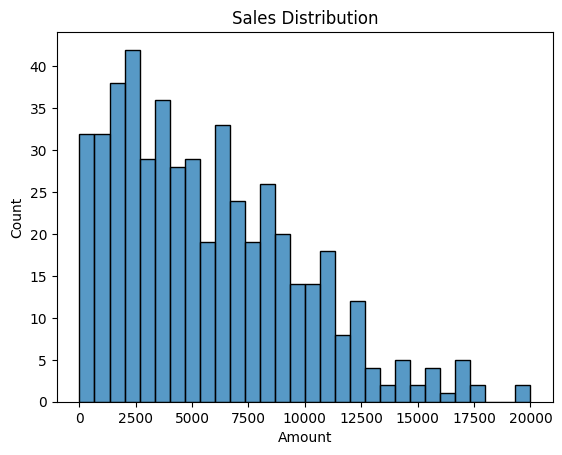

In [ ]:
sns.histplot(df["Amount"], bins=30)
plt.title("Sales Distribution")
plt.show()

In [ ]:
#sales by countries

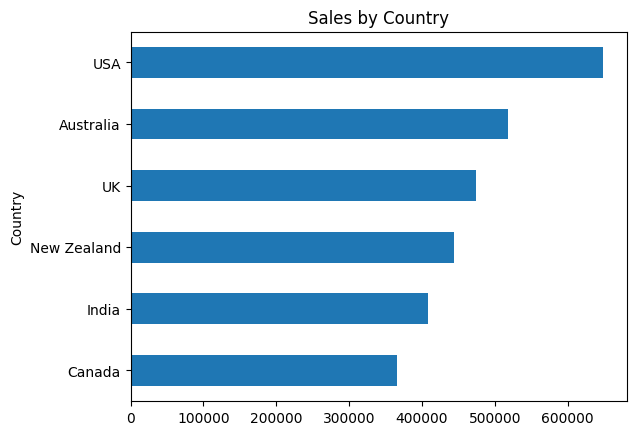

In [ ]:
df.groupby("Country")["Amount"].sum().sort_values().plot(kind="barh")
plt.title("Sales by Country")
plt.show()

In [ ]:
#sales by products

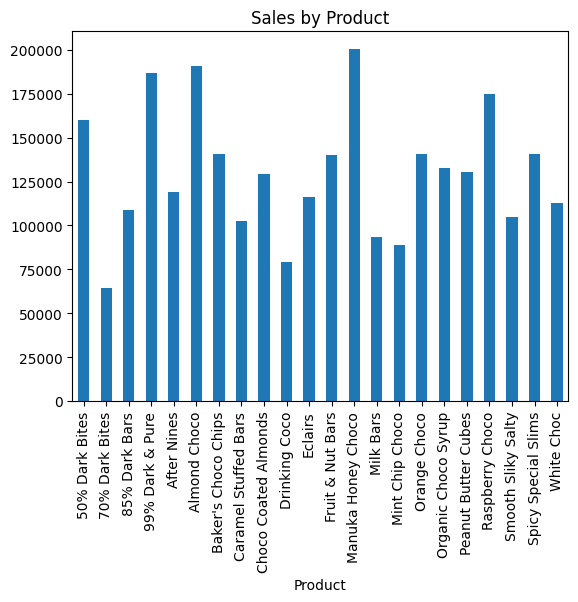

In [ ]:
df.groupby("Product")["Amount"].sum().plot(kind="bar")
plt.title("Sales by Product")
plt.show()

In [ ]:
#sales by salesperson

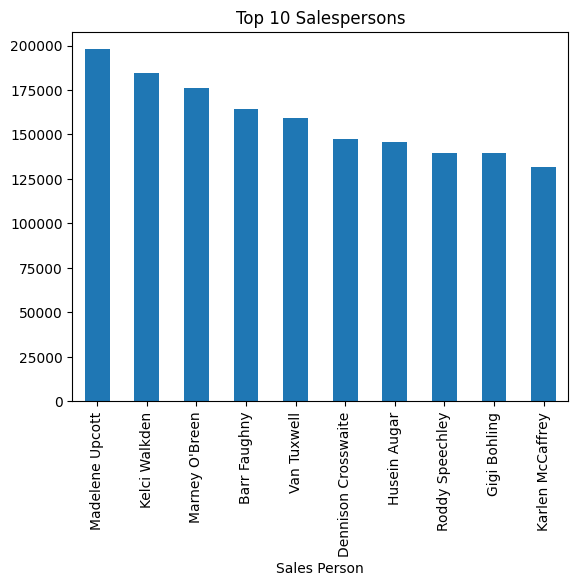

In [ ]:
df.groupby("Sales Person")["Amount"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 Salespersons")
plt.show()

In [ ]:
#monthly sales trend

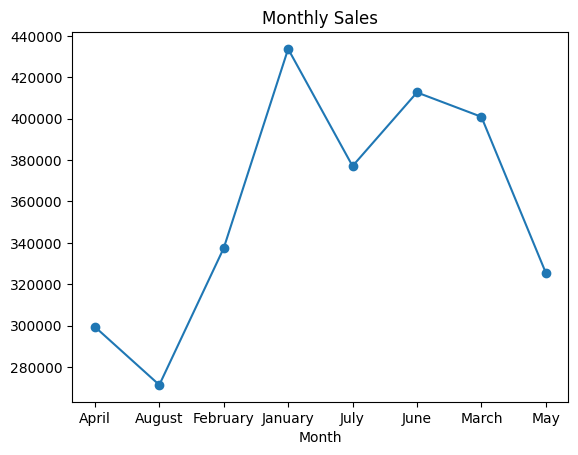

In [ ]:
monthly = df.groupby("Month")["Amount"].sum()
monthly.plot(marker="o")
plt.title("Monthly Sales")
plt.show()

In [ ]:
#correlation

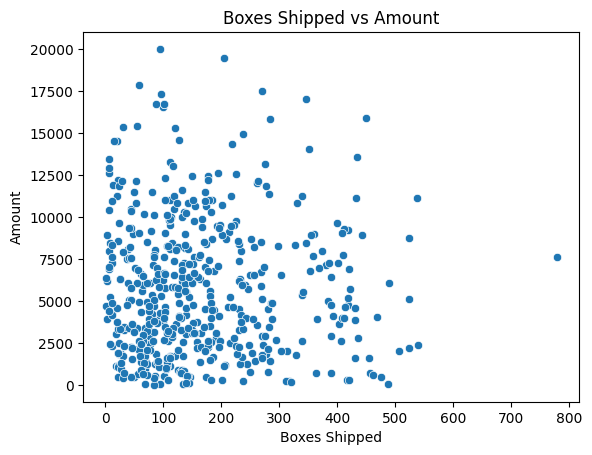

In [ ]:
sns.scatterplot(x="Boxes Shipped", y="Amount", data=df)
plt.title("Boxes Shipped vs Amount")
plt.show()

In [ ]:
#correlation heatmap

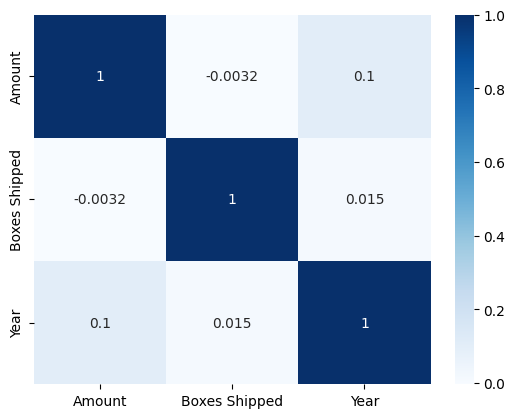

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")
plt.show()